In [9]:
# data augmentation or training set expansion
# Write a function that can shift an MNIST image in any direction by one pixel
# Create 4 shifted copies for each image
# And add to training set
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

X, y = mnist.data, mnist.target
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

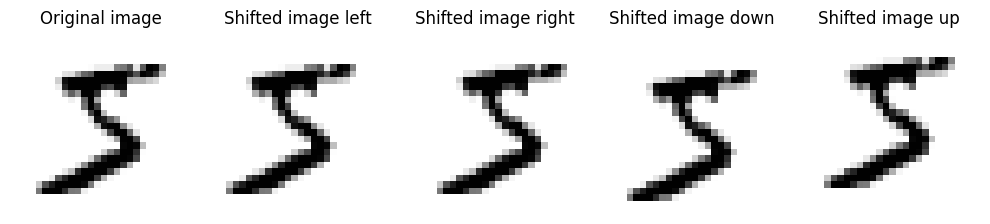

In [ ]:
# Shift a image position
import matplotlib.pyplot as plt
from scipy import ndimage
import numpy as np

# left, right, up, or down
shiftVariations = [
    [0, -1, "left"],
    [0, 1, "right"],
    [1, 0, "down"],
    [-1, 0, "up"],
]

def shift_image(image, y, x):
    return ndimage.shift(image, [y, x], cval=0, order=0)

test_image = X[0].reshape(28, 28)
# Create a figure with 1 row and N + original(1 image) columns
fig, axes = plt.subplots(1, len(shiftVariations) + 1, figsize=(10, 5))

axes[0].imshow(test_image, cmap="binary")
axes[0].set_title("Original image")
axes[0].axis("off")

for i, position in enumerate(shiftVariations):
	axesI = i + 1
	yd,xd,label = position
    # По оси 0 сдвиг y (вверх, вниз); по оси 1 ставим x (влево,вправо)
	shifted_image = shift_image(test_image, yd, xd)
	axes[axesI].imshow(shifted_image, cmap="binary")
	axes[axesI].set_title(f"Shifted image {label}")
	axes[axesI].axis("off")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

augmented_images = []
augmented_labels = []

for image, label in zip(X_train, y_train):
	# y,x в цилках могут перезаписывывать оригинал
	for yd,xd,_ in shiftVariations:
		# reshape(784) возвращаем в изначальную форму
		shifted_image = shift_image(image.reshape(28, 28), yd, xd).reshape(784)
		augmented_images.append(shifted_image)
		augmented_labels.append(label)

X_trained_augmented = np.concatenate((X_train, augmented_images))
y_trained_augmented = np.concatenate((y_train, augmented_labels))
print(X_trained_augmented.shape)
print(y_trained_augmented.shape)

(300000, 784)
(300000,)


In [ ]:
# Пробуем уже с ранее используемым KNN
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=4, weights="distance")
knn_clf.fit(X_trained_augmented, y_trained_augmented)
print("predict:",knn_clf.predict([X[0]]))
print("real:", y[0])


predict: ['5']
real: 5


In [ ]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(knn_clf, X_trained_augmented, y_trained_augmented, cv=3, scoring="accuracy", n_jobs=8)
print("score для KNeighborsClassifier на train augmented:", score)
# [0.98389 0.98128 0.98026]

score для KNeighborsClassifier на train augmented: [0.98389 0.98128 0.98026]


In [ ]:
# confusion matrix попробовать